# RTG–CTM: transfer and anticipation
### Seven-minute research brief

**Reading route:** final protocol → transfer findings → anticipation in two representations → earlier observations → limitations and feedback. The full notebook remains the reproducibility record.

## 1. Primary experiment — all B0 → B1–B4

**Question:** Can a model fitted on B0 recognize objects under the later block conditions?

- **Train:** all 318 successful B0 recordings; **test:** all 640 B1–B4 recordings, with 80 per object.
- The same participants contribute to both domains. This is cross-block transfer, not unseen-person generalization.
- Input: five fingertips × three coordinates, linearly resampled over sample index to 100 positions.
- Common crop: first `hand_active == 1` to the detected board-based lift event; no extra post-lift tail. The board channel follows the validated block-specific mapping.
- Standardization is fitted exclusively on B0 and reused unchanged.
- CTM: 256 state units, 25 internal ticks, 328,970 trainable parameters; one training seed.

**Training duration:** 15 fixed epochs, approximately 150 optimizer updates. This approximates the 152 updates of the earlier B0-only development run (19 epochs on 238 training recordings). It is a documented budget choice, not a claim that 15 epochs is optimal. No B0 validation subset remains in the final fit.

The final budget was derived from B0 development. B1–B4 were excluded from this model's fitting, although they had already been explored in earlier experiments; they were not an untouched dataset across the project.


## 2. Observation — transfer is substantial but object-dependent

| Evaluation | Accuracy |
|---|---:|
| B0 training | 99.06% |
| B1–B4, prediction at most-certain internal tick | **85.31% (546/640)** |
| B1–B4, final internal tick | 85.63% (548/640) |

“Most certain” selects the tick with the highest entropy-based certainty across the completed 25-tick run. It is a retrospective readout, not an online stopping policy. B0 training accuracy is not an independent test score.

Block accuracies are B1 **87.50%**, B2 **86.25%**, B3 **81.25%**, and B4 **86.25%**. Object differences are larger:

| Object (class) | Correct / 80 | Accuracy |
|---|---:|---:|
| Stick (0) | 70 | 87.50% |
| Ball (1) | 78 | 97.50% |
| Screw (2) | 55 | 68.75% |
| Box (3) | 75 | 93.75% |
| Knife (4) | 77 | 96.25% |
| Glass (5) | 78 | 97.50% |
| Assembly (6) | 36 | 45.00% |
| Disk (7) | 77 | 96.25% |

**Interpretation:** Screw and assembly contribute **69 of the 94 errors (73.4%)**. Assembly is difficult in every block, with accuracy between 40% and 60%. This is more informative than describing the model as uniformly weaker on the later blocks. The results do not isolate whether the cause is grasp shape, spatial cues, participant effects, extraction quality, or their combination.


## 3. Primary experiment — anticipation by movement fraction

**Question:** How does the frozen B0-trained model perform when only an initial portion of a test trajectory is supplied?

The analysis takes prefixes of the already resampled 100-position trajectories. Inputs therefore contain fewer positions at earlier fractions. No retraining is performed.

| Positions supplied | 5% | 10% | 25% | 50% | 75% | 90% | 100% |
|---|---:|---:|---:|---:|---:|---:|---:|
| Accuracy | 29.5% | 33.0% | 42.3% | 57.7% | 75.9% | 83.6% | 85.3% |

Recognition improves throughout the observed interval. These fractions refer to the normalized export, not measured elapsed-time fractions or fraction of physical distance travelled. Complete-trajectory normalization uses a retrospectively known endpoint; this is an offline prefix analysis.


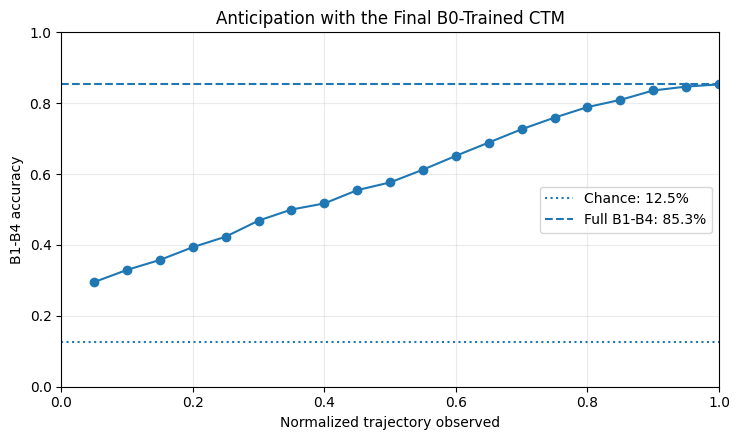

*Frozen final model: accuracy versus normalized input fraction; 640 recordings at each point.*


**Sustained correctness:** Among the 546 recordings correct at full observation, the median earliest fraction that remains correct at every later tested fraction is 30% (mean about 37%). The grid advances in 5% steps.

This is conditional on final correctness and uses future evaluated predictions to assess stability. It does not mean half of all trials can be reliably stopped at 30%. The reported proportion with any sustained-correct point equals final accuracy by construction: a final correct point alone qualifies.


## 4. Primary experiment — anticipation in physical time

**Question:** What can the same frozen model recognize from observations available at fixed times before the detected lift?

Raw glove observations are first truncated using timestamps. Each available prefix is then resampled to **100 positions**, and the B0 scaler is applied. Fewer than two available raw samples makes a recording ineligible at that cutoff. No observation after the cutoff enters this resampling step.

| Lead before detected lift | Eligible trials | Accuracy | Same 608-trial cohort |
|---|---:|---:|---:|
| 500 ms | 608 | 53.29% | 53.29% |
| 400 ms | 615 | 62.11% | 62.01% |
| 300 ms | 626 | 69.81% | 69.57% |
| 200 ms | 629 | 77.90% | 77.80% |
| 100 ms | 629 | 82.99% | 82.89% |
| 0 ms | 640 | 85.31% | 85.03% |

The common cohort confirms that changing eligibility does not explain the overall rise. It represents recordings supporting the earliest cutoff, rather than all recordings. Actual last observations generally precede the requested cutoff slightly because sampling is discrete.

**Important distinction:** This analysis stretches each available prefix to 100 positions; the fraction analysis simply shortens the full normalized input. The two support a similar qualitative pattern, but are not interchangeable measurements under an identical representation. Their agreement does not establish equivalence.


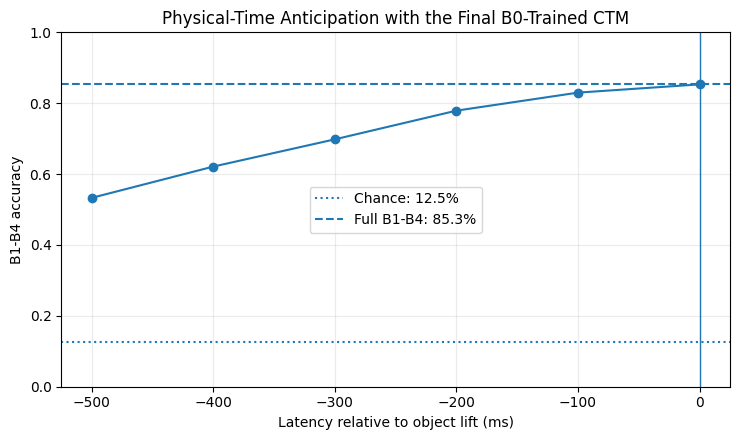

*Physical-time anticipation using all eligible recordings; see the table for fixed-cohort confirmation.*


## 5. Observation — early recognition differs by object

Disk is already recognized in about 93% of eligible recordings 500 ms before lift. Knife rises from about 16% at that cutoff to 96% at full observation. Assembly remains below 50% across the evaluated interval.

These differences suggest two questions: when useful features become available, and whether those features transfer from B0. They do not prove that later movement contains a corresponding quantity of “information.” The reported raw sample fraction is a coverage measure, not an information-theoretic measurement. Object-specific physical-time curves also have changing eligible subsets.

Early discrimination can reflect posture and spatial cues as well as evolving grasp shape. The present results establish object prediction from kinematics; they do not isolate a causal representation of intention.


## 6. Earlier exploratory observations — separate protocols

| Observation | What it establishes / limits |
|---|---|
| **96.25% (154/160)** with B1–B4 repetitions 0–1 for training, 2 for validation, 3 for testing | Recognition of new repetitions with the same participants and blocks represented during training. |
| **87.66%** transfer from the earlier partial-B0 training model | Development result with a different training subset and budget; superseded as the primary protocol by the all-B0 run. |
| Matched-prefix models outperform a full-input model on short prefixes | Training/input mismatch matters; these were held-out-repetition experiments, not results of the final B0 model. |
| Later equal-length windows generally classify better | A result of the tested models and protocol, not a direct measurement of intrinsic information content. |
| Extra tick budgets produce limited gains in the tested sweeps | Does not establish that computation can never help with missing evidence. |
| Strong Wiener noise lowers accuracy faster than certainty | Motivates studying confident errors; not a formal calibration analysis of the final model. |
| Unseen-participant mean accuracy 75.94%, with large variation | Separate exploratory protocol, five participants and one seed per fold. |

**Do not treat 96.25% → 85.31% as an isolated intervention effect.** Training domains, test populations and model-selection procedures differ. The earlier split was by repetition, not a random split of time samples.

## 7. What is established, and what feedback is useful?

**Established for this run:** B0-fitted CTM transfers to later blocks; useful predictive performance is present before the detected lift; errors and anticipation differ substantially by object.

**Limits:** one training seed; five participants; repeated observations within participant/block/trial; some very short source-defined crops; prior exploration of the test domain; no independent baseline comparison here establishing CTM superiority. No significance or causal effect is claimed. The summary uses saved outputs, not a fresh end-to-end execution.

**Feedback from Dr. Dario:**
1. Do these results support the intended cross-block transfer and anticipation interpretation, with the two input-normalization conventions stated separately?
2. Do screw/assembly errors suggest a useful dataset-specific interpretation to check before attributing them to the model?
3. Is the final frozen all-B0 model an appropriate starting point for population/evidence-accumulation analysis, including both correct and incorrect trials?

The next stage should analyse activity across internal ticks of this fixed model. Earlier held-out-repetition tick/noise results motivate that work, but are not yet measurements of its internal dynamics.

---
# Progress update — 28 September 2026

The preceding brief is retained unchanged as the previous report. The following experiments extend it with direct variable-length testing and participant-specific CTMs. All tables and figures below report the follow-up; no earlier results are replaced.

The pooled checkpoint reproduces **85.31% most-certain-tick accuracy** and **85.63% final-tick accuracy** on B1–B4. Its configuration was reconstructed from current defaults and the final protocol, then saved; the original run lacked an archived configuration.

## 8. Physical-time anticipation with raw variable-length inputs

The frozen CTM now receives timestamp-cut raw prefixes directly, scaled with the saved B0 scaler. **No resampling to 100 positions, padding, masking or artificial noise is required.** Some raw inputs exceed 100 frames; input length and the model’s 25 internal ticks remain distinct.

Both representations use the same eligible recordings at each cutoff. Recordings with fewer than two available samples are excluded.

| Time before endpoint | Eligible recordings | Median raw frames | Pooled: resampled to 100 | Pooled: raw length |
|---|---:|---:|---:|---:|
| 500 ms | 608 | 29 | 53.29% | 53.45% |
| 400 ms | 615 | 35 | 62.11% | 62.28% |
| 300 ms | 626 | 41 | 69.81% | 69.97% |
| 200 ms | 629 | 47 | 77.90% | 78.06% |
| 100 ms | 629 | 53 | 82.99% | 83.31% |
| 0 ms | 640 | 60 | 85.31% | 85.31% |

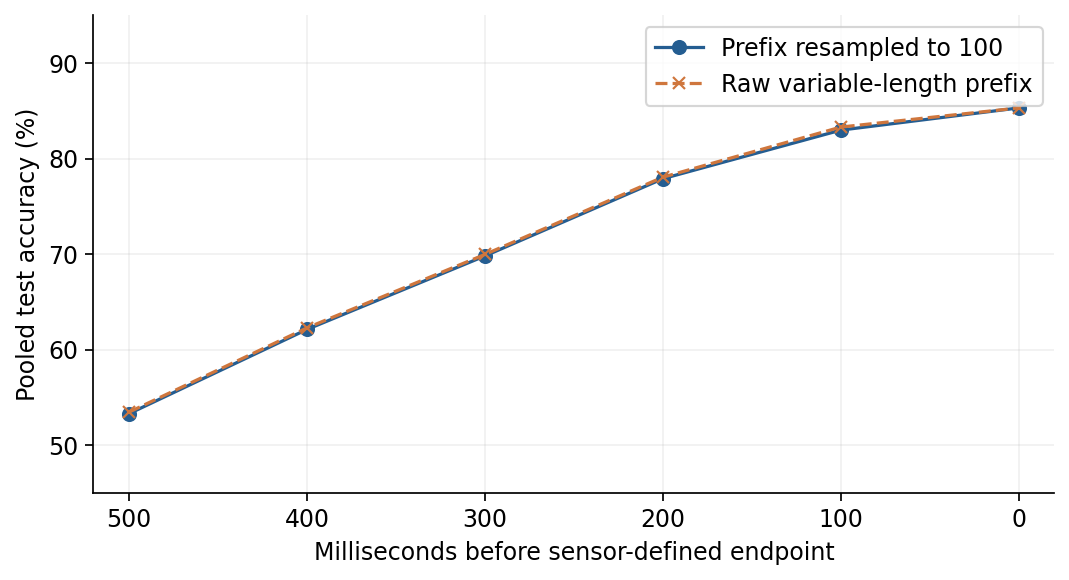

Figure 2. The frozen pooled CTM gives nearly overlapping anticipation curves. Each point uses all eligible recordings at that cutoff; denominators are listed above.

The largest aggregate accuracy difference is approximately **0.32 percentage points**. On the fixed cohort of 608 recordings eligible at every cutoff, raw accuracy rises from **53.45% to 85.03%**, and representation agreement remains close.

The early-recognition result therefore appears robust to stretching versus directly supplying the available prefix. This does not establish identical internal activity. Cutoffs remain relative to the sensor-defined endpoint and constitute retrospective anticipation analysis, not an online stopping policy.

## 9. Participant-specific training versus pooled training

Five specialist CTMs were trained separately on each participant’s B0 and tested only on that participant’s B1–B4. Each uses its own B0-fitted scaler. The pooled comparison uses the same test recordings.

Architecture, seed and **150 optimizer updates per model** are held fixed. Specialists require 75 epochs versus 15 pooled epochs because their training sets are smaller. This matches updates per model, not epochs, exposure per recording or total compute across five models.

| Participant | Pooled | Own-participant CTM | Difference |
|---|---:|---:|---:|
| P1 | 79.69% | 73.44% | -6.25 pp |
| P2 | 84.38% | 86.72% | +2.34 pp |
| P3 | 82.81% | 86.72% | +3.91 pp |
| P4 | 93.75% | 92.19% | -1.56 pp |
| P5 | 85.94% | 80.47% | -5.47 pp |
| **All recordings** | **85.31% (546/640)** | **83.91% (537/640)** | **−1.41 pp** |

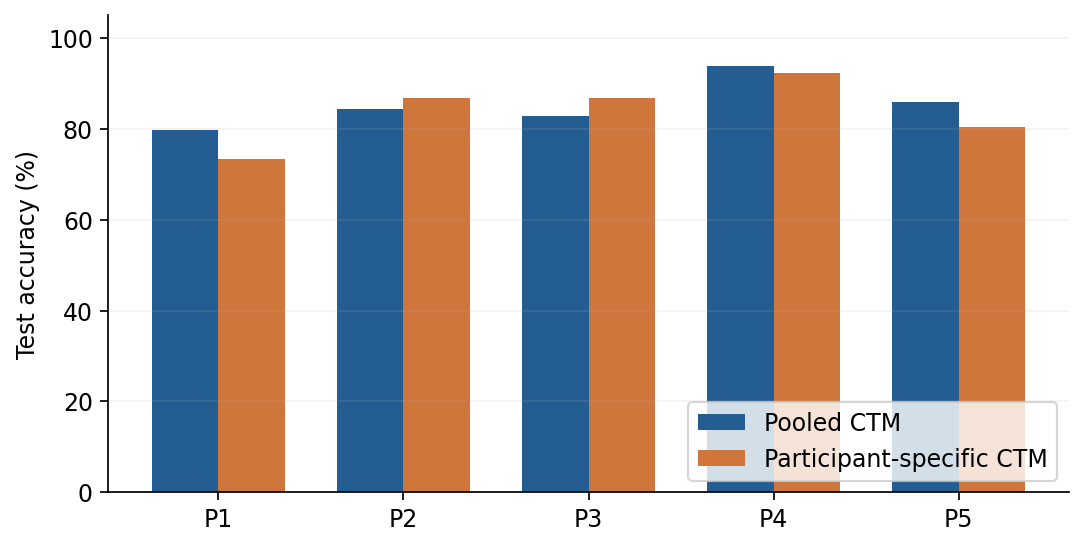

Figure 1. Full-trajectory B0 → B1–B4 transfer, 128 test recordings per participant. One seed; bars are descriptive, without uncertainty estimates.

Specialists improve P2 and P3 but reduce performance for P1, P4 and P5. Their aggregate is **nine fewer correct recordings**. Final-tick accuracy is **84.06% specialist versus 85.63% pooled**. There is no consistent full-trajectory specialist advantage under this training rule.

Each participant contributes 128 test recordings, so mean participant accuracy equals recording-weighted accuracy here. These are one-seed descriptive comparisons, not evidence of statistical superiority.

## 10. Training strategy and early recognition

Both model types were evaluated with raw prefixes at identical physical cutoffs. Specialist accuracies below are weighted by eligible recording count; eligibility varies across participants at early cutoffs.

| Time before endpoint | Pooled CTM | Participant-specific CTMs | Specialist minus pooled |
|---|---:|---:|---:|
| 500 ms | 53.45% | 58.06% | +4.61 pp |
| 400 ms | 62.28% | 63.58% | +1.30 pp |
| 300 ms | 69.97% | 69.17% | -0.80 pp |
| 200 ms | 78.06% | 74.88% | -3.18 pp |
| 100 ms | 83.31% | 80.45% | -2.86 pp |
| 0 ms | 85.31% | 83.91% | -1.41 pp |

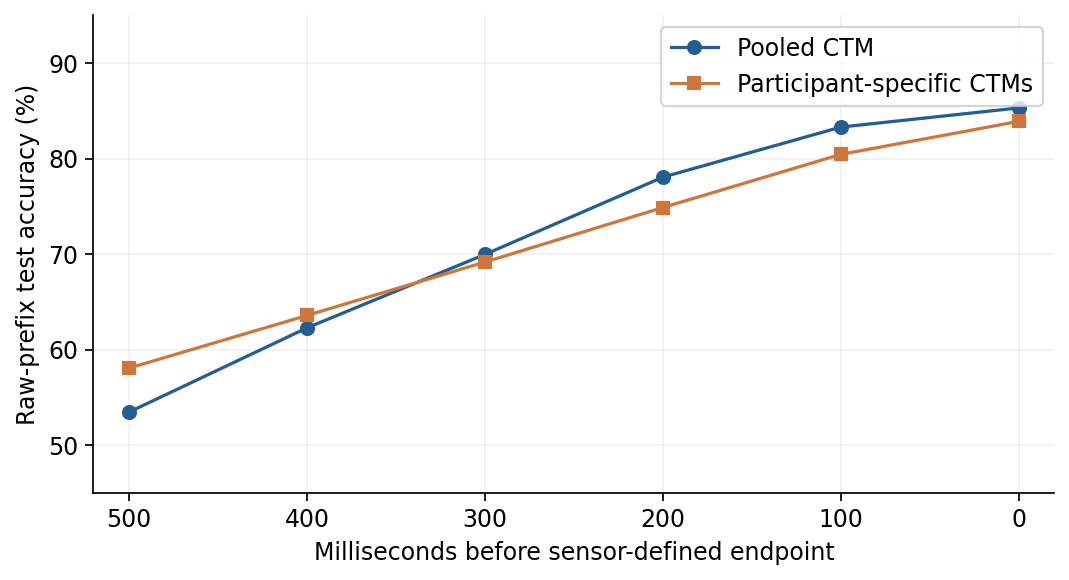

Figure 3. Specialists lead at the earliest cutoffs; the pooled model leads nearer lift. These are separate frozen models evaluated on matched inputs at each cutoff.

Specialists lead at **500 and 400 ms**; the pooled model leads from **300 ms onward**. The strongest full-trajectory aggregate is therefore not necessarily the strongest early-prefix aggregate in this run.

For specialists, prediction disagreement between raw and resampled representations is below 1% **after aggregating participants at each cutoff**, but reaches **1.77%** for an individual participant/cutoff. Equal accuracy can conceal changed individual predictions.